In [69]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD/wesad_readme.pdf
/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD/S14/S14.pkl
/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD/S14/S14_quest.csv
/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD/S14/S14_respiban.txt
/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD/S14/S14_readme.txt
/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD/S14/S14_E4_Data/HR.csv
/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD/S14/S14_E4_Data/IBI.csv
/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD/S14/S14_E4_Data/BVP.csv
/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD/S14/S14_E4_Data/EDA.csv
/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-da

In [70]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file == "S2.pkl":
            print(os.path.join(root, file))

/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD/S2/S2.pkl


In [71]:
# Step 0: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load the dataset
# We'll decide which modality to use: e.g., chest ECG, wrist sensors
data_path = "/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD"  # adjust if needed

In [72]:
import pickle

# Path to one subject's data (adjust if needed)
subject_path = "/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD/S2/S2.pkl"

# Load the data
with open(subject_path, "rb") as f:
    subject_data = pickle.load(f, encoding='latin1')

# Check the keys in the data
print(subject_data.keys())


dict_keys(['signal', 'label', 'subject'])


In [73]:
chest = subject_data['signal']['chest']  # 2D array [samples x channels]
wrist = subject_data['signal']['wrist']  # 2D array [samples x channels]
labels = subject_data['label']            # 1D array [samples]
subject = subject_data['subject']         # string

print(chest.keys())  # e.g., (204000, 8)
print(wrist.keys())  # e.g., (204000, 7)
print(labels.shape) # e.g., (204000,)


dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])
dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])
(4255300,)


In [74]:
chest['ACC'].shape


(4255300, 3)

In [75]:
wrist['ACC'].shape


(194528, 3)

In [76]:
chest['ECG'].shape

(4255300, 1)

In [77]:
print(subject_data['label'].shape)

(4255300,)


In [78]:
print(labels[:100])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [79]:
print(np.unique(labels))
# Output: [0 1 2 3]
pd.Series(labels).value_counts()


[0 1 2 3 4 6 7]


0    2142701
1     800800
4     537599
2     430500
3     253400
6      45500
7      44800
Name: count, dtype: int64

In [80]:
# Example: check the available sensors
print(subject_data['signal'].keys())
print(subject_data['signal']['chest'].keys())
print(subject_data['signal']['wrist'].keys())


# Example: look at ECG values
ecg_data = subject_data['signal']['chest']['ECG']
print(ecg_data.shape)
print(ecg_data[:10])  # first 10 samples

dict_keys(['chest', 'wrist'])
dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])
dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])
(4255300, 1)
[[0.02142334]
 [0.02032471]
 [0.01652527]
 [0.01670837]
 [0.01167297]
 [0.00489807]
 [0.00279236]
 [0.00608826]
 [0.00993347]
 [0.01039124]]


In [81]:
# Example: check the available sensors
print(subject_data['signal'].keys())

# Example: look at ECG values
ecg_chest_data = subject_data['signal']['chest']['ECG']
print(ecg_chest_data.shape)
print(ecg_chest_data[:10]) 
  # first 10 samples


dict_keys(['chest', 'wrist'])
(4255300, 1)
[[0.02142334]
 [0.02032471]
 [0.01652527]
 [0.01670837]
 [0.01167297]
 [0.00489807]
 [0.00279236]
 [0.00608826]
 [0.00993347]
 [0.01039124]]


In [82]:
acc_chest_data = subject_data['signal']['chest']['ACC']
acc_chest_data

array([[ 0.95539999, -0.222     , -0.55799997],
       [ 0.92579997, -0.2216    , -0.55379999],
       [ 0.90820003, -0.21960002, -0.53920001],
       ...,
       [ 0.87179995, -0.12379998, -0.30419999],
       [ 0.87300003, -0.12339997, -0.30260003],
       [ 0.87020004, -0.12199998, -0.30220002]])

In [83]:
labels = subject_data['label']
print(labels.shape)
print(np.unique(labels))  # shows 0,1,2,... for different states


(4255300,)
[0 1 2 3 4 6 7]


In [84]:
labels = subject_data['label']
labels_series = pd.Series(labels)

# Count of each label
counts = labels_series.value_counts().sort_index()
print(counts)

0    2142701
1     800800
2     430500
3     253400
4     537599
6      45500
7      44800
Name: count, dtype: int64


In [85]:
import numpy as np

# Original labels
labels = subject_data['label']

# Identify indices to keep (ignore 5, 6, 7)
keep_indices = np.isin(labels, [0,1,2,3,4])

# Filter labels
labels_clean = labels[keep_indices]

# Filter ECG (or any other sensor) correspondingly
ecg_clean = ecg_data[keep_indices]

# Check shapes
print("Filtered ECG shape:", ecg_clean.shape)
print("Filtered labels shape:", labels_clean.shape)

# Check unique labels after filtering
print("Unique labels:", np.unique(labels_clean))


Filtered ECG shape: (4165000, 1)
Filtered labels shape: (4165000,)
Unique labels: [0 1 2 3 4]


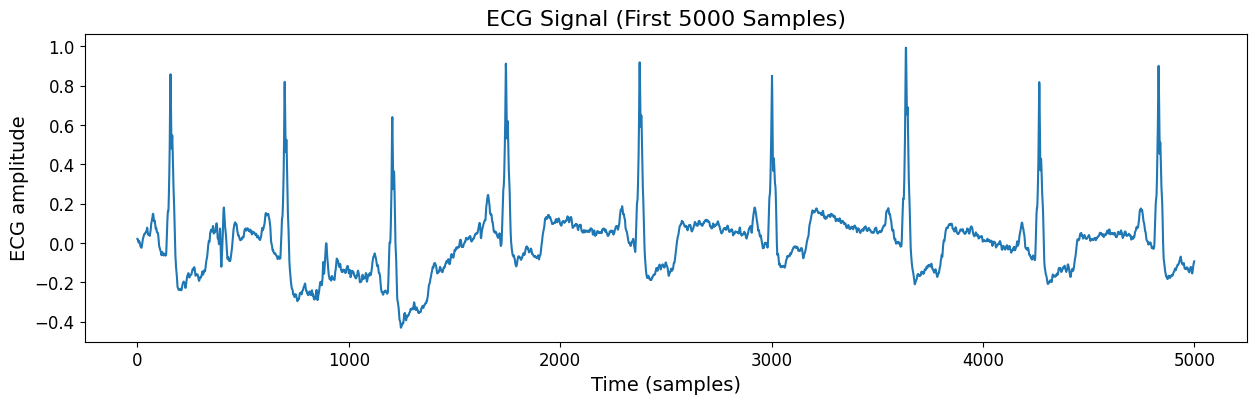

In [86]:


# ECG data for the subject
ecg_data = subject_data['signal']['chest']['ECG']

# Plot first 5000 samples (for visibility)
plt.figure(figsize=(15,4))
plt.plot(ecg_data[:5000])
plt.title("ECG Signal (First 5000 Samples)")
plt.xlabel("Time (samples)")
plt.ylabel("ECG amplitude")
plt.show()


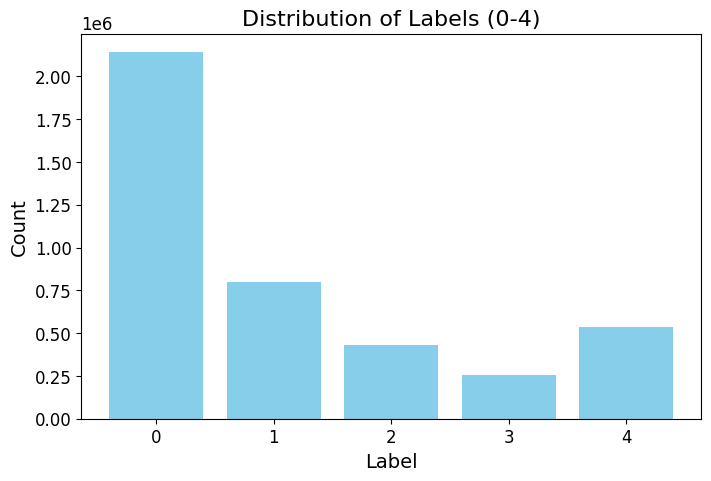

In [87]:

# Convert to pandas Series
labels_series = pd.Series(labels_clean)

# Count of each label
counts = labels_series.value_counts().sort_index()

# Plot bar chart
plt.figure(figsize=(8,5))
plt.bar(counts.index, counts.values, color='skyblue')
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of Labels (0-4)")
plt.show()


In [88]:
# Make sure ECG is 1-D
ecg_signal = ecg_clean

# If it's 2-D, flatten it
if ecg_signal.ndim > 1:
    ecg_signal = ecg_signal[:,0]  # take first channel

print("ECG shape after flattening:", ecg_signal.shape)

ECG shape after flattening: (4165000,)


In [89]:
from scipy.signal import find_peaks
peaks, _ = find_peaks(ecg_signal, distance=200)

print("Number of detected peaks:", len(peaks))



Number of detected peaks: 16350


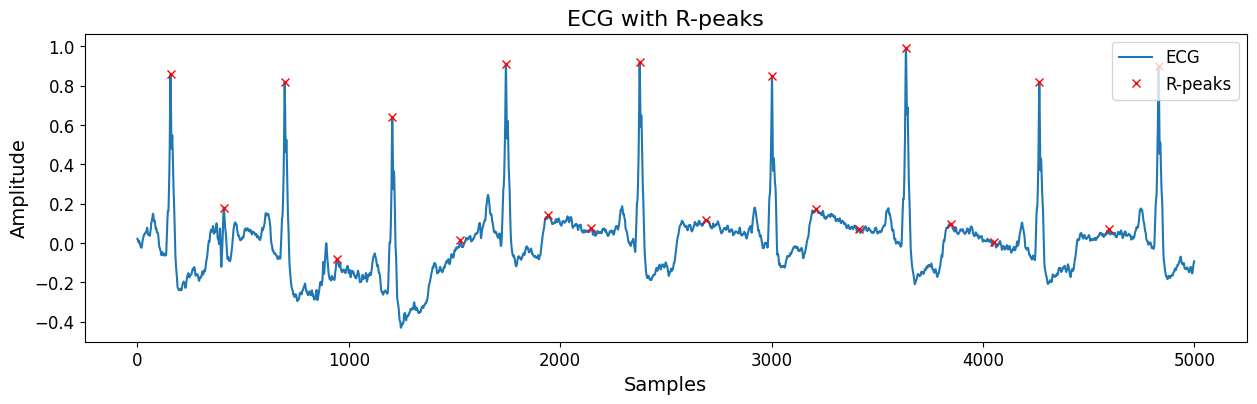

In [90]:
plt.figure(figsize=(15,4))
plt.plot(ecg_signal[:5000], label='ECG')
plt.plot(peaks[peaks<5000], ecg_signal[peaks[peaks<5000]], 'rx', label='R-peaks')
plt.title("ECG with R-peaks")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

In [91]:
# Assuming sampling rate = 700 Hz for chest ECG
fs = 700

# RR intervals in seconds
rr_intervals = np.diff(peaks) / fs
print("First 10 RR intervals (s):", rr_intervals[:10])


First 10 RR intervals (s): [0.36       0.41142857 0.35142857 0.37571429 0.46       0.30714286
 0.28571429 0.28714286 0.33142857 0.44857143]


In [92]:
mean_rr = np.mean(rr_intervals)
std_rr = np.std(rr_intervals)
heart_rate = 60 / mean_rr  # bpm
hrv = std_rr  # simple HRV measure (SDNN)

print(f"Mean RR: {mean_rr:.3f}s, Heart Rate: {heart_rate:.2f} bpm, HRV: {hrv:.3f}")


Mean RR: 0.364s, Heart Rate: 164.87 bpm, HRV: 0.093


In [93]:

window_size = 5 * fs  # 5 sec
step_size = window_size // 2  # 50% overlap

features = []
window_labels = []

for start in range(0, len(ecg_clean) - window_size, step_size):
    end = start + window_size
    window_signal = ecg_clean[start:end]

    # If it's 2-D, flatten it
    if window_signal.ndim > 1:
        window_signal = window_signal[:,0]  # take first channel
    
    # R-peak detection
    peaks, _ = find_peaks(window_signal, distance=200)
    
    # Skip windows with too few peaks
    if len(peaks) < 2:
        continue
    
    rr_intervals = np.diff(peaks) / fs
    
    # Features
    mean_rr = np.mean(rr_intervals)
    std_rr = np.std(rr_intervals)
    heart_rate = 60 / mean_rr
    hrv = std_rr
    
    features.append([mean_rr, std_rr, heart_rate, hrv])
    
    # Label for this window (most frequent label in the segment)
    window_label = labels_clean[start:end]
    counts = np.bincount(window_label)
    window_labels.append(np.argmax(counts))

# Convert to numpy arrays
ecg_features = np.array(features)
ecg_window_labels = np.array(window_labels)

print("Features shape:", ecg_features.shape)

print("Window labels shape:", ecg_window_labels.shape)


Features shape: (2378, 4)
Window labels shape: (2378,)


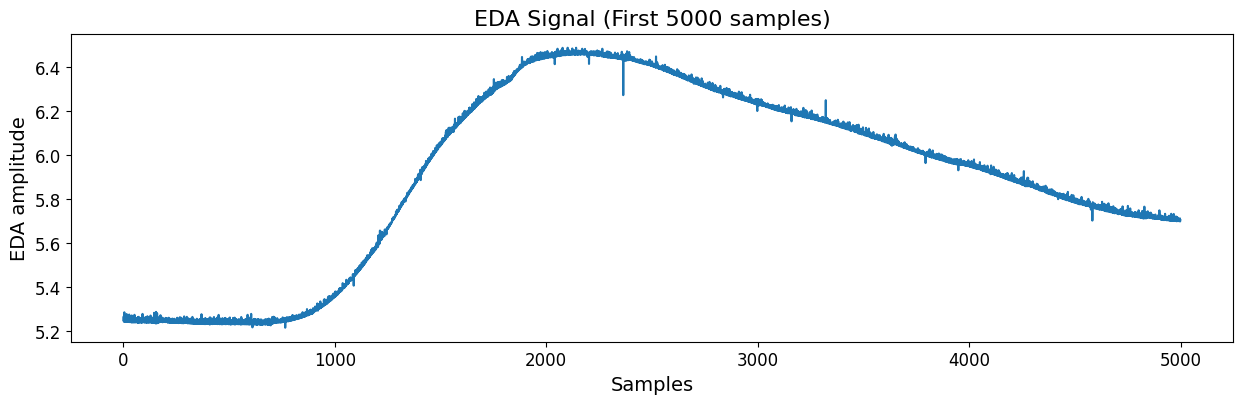

In [94]:
# EDA signal from chest
eda_signal = subject_data['signal']['chest']['EDA']

plt.figure(figsize=(15,4))
plt.plot(eda_signal[:5000])
plt.title("EDA Signal (First 5000 samples)")
plt.xlabel("Samples")
plt.ylabel("EDA amplitude")
plt.show()
#Peaks correspond to skin conductance responses (SCR), often triggered by stress or arousal

In [95]:
print("EDA Mean:", np.mean(eda_signal))
print("EDA Std:", np.std(eda_signal))
print("EDA Min/Max:", np.min(eda_signal), np.max(eda_signal))


EDA Mean: 1.5283874467075147
EDA Std: 1.238424840251519
EDA Min/Max: 0.263214111328125 7.576751708984375


In [96]:
print(eda_signal.shape)

(4255300, 1)


In [97]:
# Match label length to EDA signal length
labels_resampled = np.repeat(labels_clean, len(eda_signal) // len(labels_clean) + 1)
labels_resampled = labels_resampled[:len(eda_signal)]


In [98]:
from scipy.signal import find_peaks

window_size = 5 * fs  # same as ECG
step_size = window_size // 2

eda_features = []
eda_window_labels = []

for start in range(0, len(eda_signal) - window_size, step_size):
    end = start + window_size
    window = eda_signal[start:end]

    # If it's 2-D, flatten it
    if window.ndim > 1:
        window = window[:,0]  # take first channel

    # Features
    mean_val = np.mean(window)
    std_val = np.std(window)
    max_val = np.max(window)
    min_val = np.min(window)
    
    peaks, _ = find_peaks(window, height=np.mean(window))
    num_peaks = len(peaks)
    
    eda_features.append([mean_val, std_val, max_val, min_val, num_peaks])
    
    # Label for this window
    window_label = labels_resampled[start:end]
    if len(window_label) == 0:
        continue
    counts = np.bincount(window_label)
    eda_window_labels.append(np.argmax(counts))

# Convert to numpy arrays
eda_features = np.array(eda_features)
eda_window_labels = np.array(eda_window_labels)

print("EDA features shape:", eda_features.shape)
print("EDA window labels shape:", eda_window_labels.shape)
np.unique(eda_window_labels, return_counts=True)


EDA features shape: (2430, 5)
EDA window labels shape: (2430,)


(array([0, 1, 2]), array([1023,  915,  492]))

ACC shape: (4255300, 3)


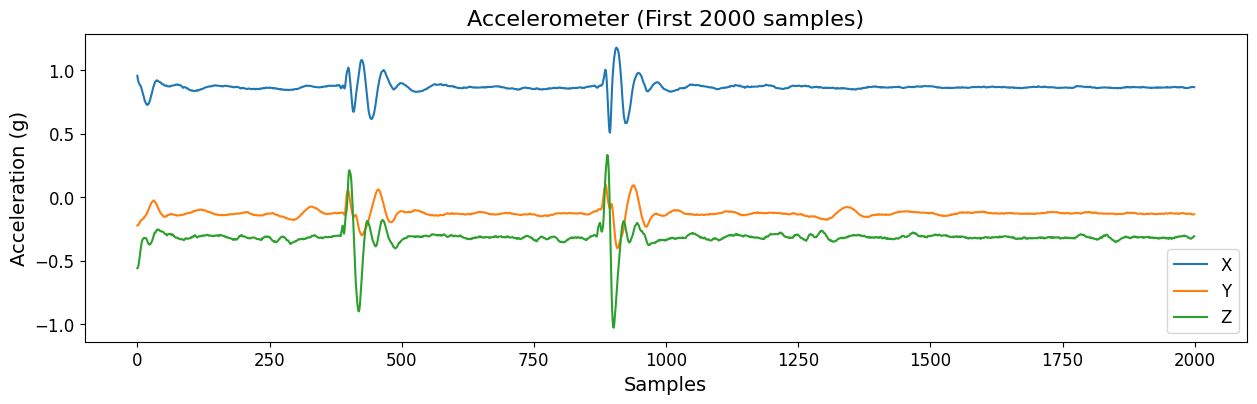

In [99]:
acc_signal = subject_data['signal']['chest']['ACC']  # shape: (n_samples, 3)
print("ACC shape:", acc_signal.shape)

plt.figure(figsize=(15,4))
plt.plot(acc_signal[:2000, 0], label='X')
plt.plot(acc_signal[:2000, 1], label='Y')
plt.plot(acc_signal[:2000, 2], label='Z')
plt.title("Accelerometer (First 2000 samples)")
plt.xlabel("Samples")
plt.ylabel("Acceleration (g)")
plt.legend()
plt.show()


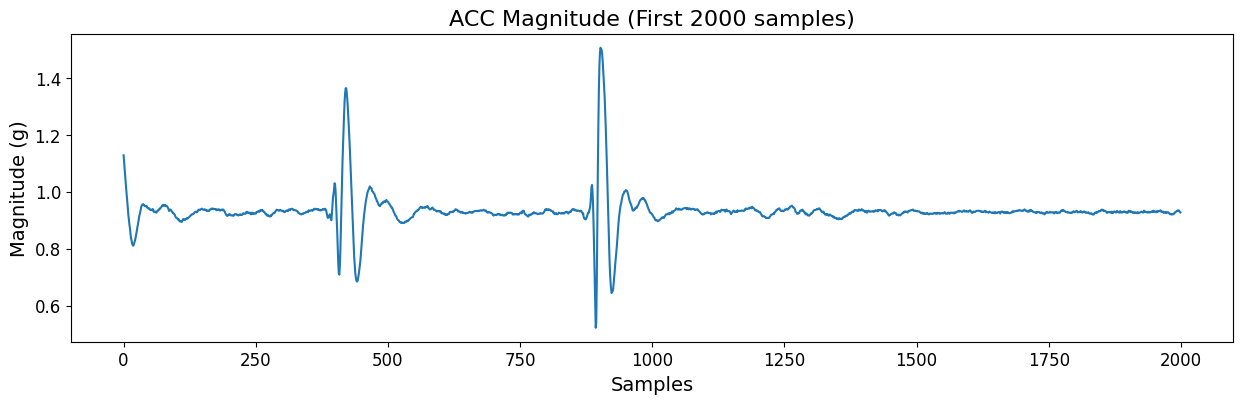

In [100]:
acc_magnitude = np.sqrt(np.sum(acc_signal**2, axis=1))

plt.figure(figsize=(15,4))
plt.plot(acc_magnitude[:2000])
plt.title("ACC Magnitude (First 2000 samples)")
plt.xlabel("Samples")
plt.ylabel("Magnitude (g)")
plt.show()


In [101]:
acc_features = []
acc_window_labels = []

# Resample labels to match ACC signal length
labels_resampled = np.repeat(labels_clean, len(acc_magnitude) // len(labels_clean) + 1)
labels_resampled = labels_resampled[:len(acc_magnitude)]

for start in range(0, len(acc_magnitude) - window_size, step_size):
    end = start + window_size
    window = acc_magnitude[start:end]
    
    # Skip empty windows
    if len(window) == 0:
        continue
    
    # Basic statistical features
    mean_val = np.mean(window)
    std_val = np.std(window)
    max_val = np.max(window)
    min_val = np.min(window)
    rms = np.sqrt(np.mean(window**2))  # root mean square
    
    acc_features.append([mean_val, std_val, max_val, min_val, rms])
    
    # Label for this window
    window_label = labels_resampled[start:end]
    counts = np.bincount(window_label)
    acc_window_labels.append(np.argmax(counts))

acc_features = np.array(acc_features)
acc_window_labels = np.array(acc_window_labels)

print("ACC features shape:", acc_features.shape)
print("ACC window labels shape:", acc_window_labels.shape)


ACC features shape: (2430, 5)
ACC window labels shape: (2430,)


In [102]:
unique, counts = np.unique(acc_window_labels, return_counts=True)
print(dict(zip(unique, counts)))


{np.int64(0): np.int64(1023), np.int64(1): np.int64(915), np.int64(2): np.int64(492)}


TEMP shape: (4255300, 1)


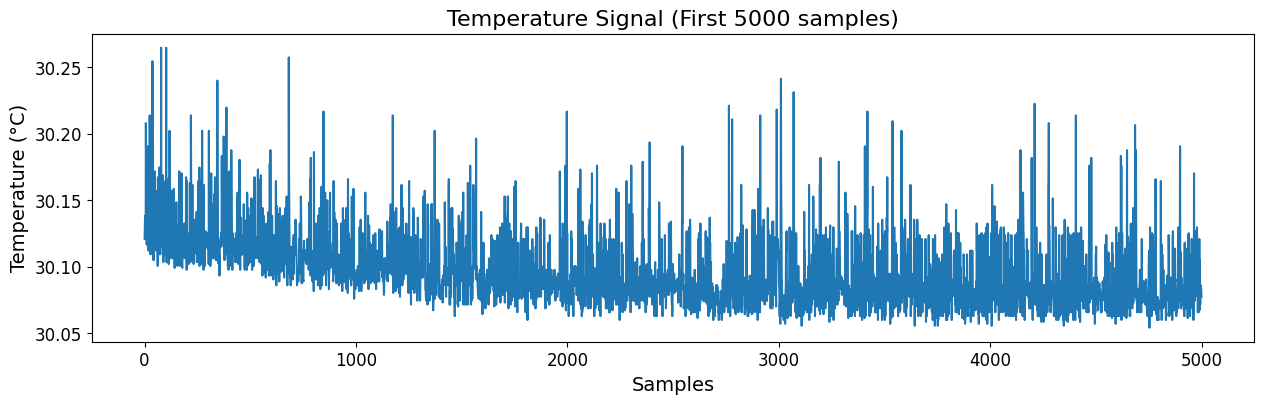

In [103]:
temp_signal = subject_data['signal']['chest']['Temp']
print("TEMP shape:", temp_signal.shape)

plt.figure(figsize=(15,4))
plt.plot(temp_signal[:5000])
plt.title("Temperature Signal (First 5000 samples)")
plt.xlabel("Samples")
plt.ylabel("Temperature (°C)")
plt.show()


In [104]:
labels_resampled = np.repeat(labels_clean, len(temp_signal) // len(labels_clean) + 1)
labels_resampled = labels_resampled[:len(temp_signal)]


In [105]:
temp_features = []
temp_window_labels = []

for start in range(0, len(temp_signal) - window_size, step_size):
    end = start + window_size
    window = temp_signal[start:end]
    
    # Skip empty or NaN windows
    if len(window) == 0 or np.isnan(window).any():
        continue
    
    # Compute scalar features safely
    mean_val = float(np.mean(window))
    std_val = float(np.std(window))
    max_val = float(np.max(window))
    min_val = float(np.min(window))
    slope = float((window[-1] - window[0]) / len(window))
    
    temp_features.append([mean_val, std_val, max_val, min_val, slope])
    
    window_label = labels_resampled[start:end]
    if len(window_label) == 0:
        continue
    counts = np.bincount(window_label)
    temp_window_labels.append(np.argmax(counts))

# Convert to numpy arrays
temp_features = np.array(temp_features, dtype=float)
temp_window_labels = np.array(temp_window_labels, dtype=int)

print("TEMP features shape:", temp_features.shape)
print("TEMP window labels shape:", temp_window_labels.shape)


/tmp/ipykernel_49/1503991927.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  slope = float((window[-1] - window[0]) / len(window))


TEMP features shape: (2430, 5)
TEMP window labels shape: (2430,)


In [106]:
unique, counts = np.unique(temp_window_labels, return_counts=True)
print(dict(zip(unique, counts)))


{np.int64(0): np.int64(1023), np.int64(1): np.int64(915), np.int64(2): np.int64(492)}


In [107]:
print("ECG:", ecg_features.shape)
print("EDA:", eda_features.shape)
print("ACC:", acc_features.shape)
print("TEMP:", temp_features.shape)


ECG: (2378, 4)
EDA: (2430, 5)
ACC: (2430, 5)
TEMP: (2430, 5)


In [108]:
# Ensure all have the same number of windows
min_len = min(len(ecg_features), len(eda_features), len(acc_features), len(temp_features))
print("Trimming all to length:", min_len)

# Trim all to same size
ecg_f = ecg_features[:min_len]
eda_f = eda_features[:min_len]
acc_f = acc_features[:min_len]
temp_f = temp_features[:min_len]

# Combine horizontally (feature-wise)
final_features = np.hstack([ecg_f, eda_f, acc_f, temp_f])
final_labels = ecg_window_labels[:min_len]  # labels are aligned per window

print("Final features shape:", final_features.shape)
print("Final labels shape:", final_labels.shape)


Trimming all to length: 2378
Final features shape: (2378, 19)
Final labels shape: (2378,)


In [109]:
df = pd.DataFrame(final_features)
df['label'] = final_labels

print(df['label'].value_counts())
df.head()


label
0    1223
1     458
4     306
2     246
3     145
Name: count, dtype: int64


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,label
0,0.361209,0.060182,166.108914,0.060182,5.917726,0.483973,6.488419,5.216217,804.0,0.930920,0.048987,1.506039,0.522995,0.932208,30.099476,0.025185,30.264648,30.055450,-9.530204e-06,0
1,0.355204,0.075161,168.916978,0.075161,6.090188,0.264621,6.488419,5.694199,694.0,0.929087,0.004193,0.944997,0.911923,0.929096,30.087017,0.021747,30.241394,30.053986,-1.286970e-05,0
2,0.360879,0.079222,166.260658,0.079222,5.809054,0.103872,6.124496,5.694199,357.0,0.929483,0.003960,0.941979,0.911923,0.929492,30.087456,0.022384,30.237030,30.053986,4.185268e-07,0
3,0.359121,0.075480,167.074663,0.075480,5.686827,0.084679,5.852509,5.527496,826.0,0.929493,0.005278,0.943932,0.906349,0.929508,30.087107,0.024126,30.239929,30.030792,-3.322056e-06,0
4,0.383690,0.080598,156.376047,0.080598,5.561679,0.061022,5.750656,5.466461,675.0,0.928444,0.019945,1.025113,0.824070,0.928658,30.062988,0.032680,30.239929,30.004700,-2.404785e-05,0


In [110]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    final_features, final_labels, test_size=0.2, random_state=42, stratify=final_labels
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (1902, 19)
Test shape: (476, 19)


In [111]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,       # keep it shallow for interpretability
    random_state=42
)
dt.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

Accuracy: 0.8928571428571429

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.90       245
           1       1.00      0.92      0.96        92
           2       0.79      0.98      0.87        49
           3       0.80      0.69      0.74        29
           4       0.94      0.79      0.86        61

    accuracy                           0.89       476
   macro avg       0.88      0.86      0.87       476
weighted avg       0.90      0.89      0.89       476



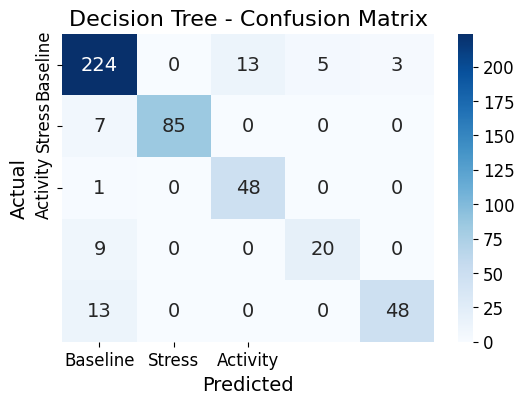

In [112]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baseline','Stress','Activity'],
            yticklabels=['Baseline','Stress','Activity'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")
plt.show()


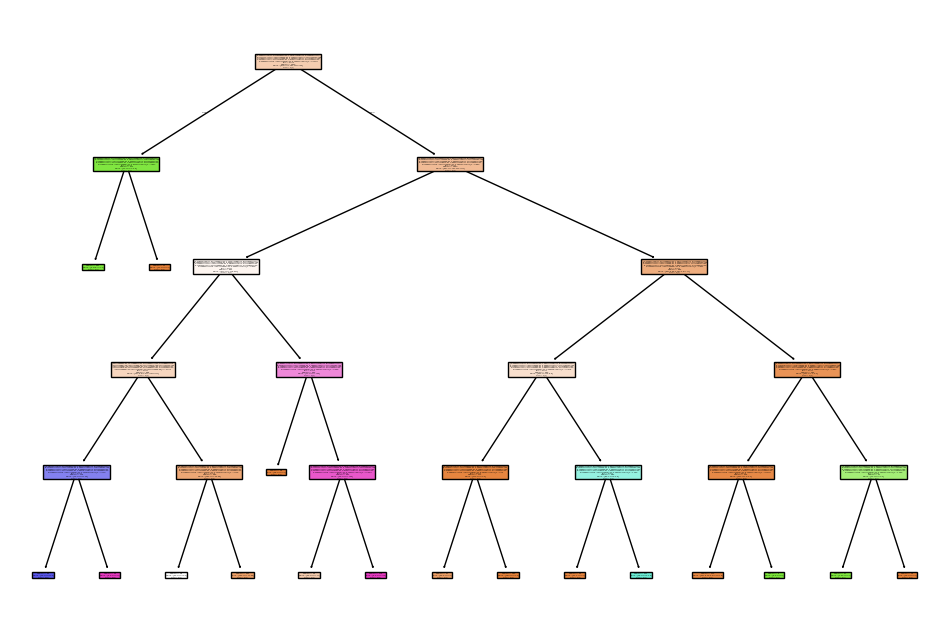

In [113]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.rcParams.update({
    'figure.figsize': (20, 15),     # larger figure size
    'font.size': 14,               # bigger text
    'axes.titlesize': 16,          # title size
    'axes.labelsize': 14,          # axis label size
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'lines.linewidth': 1.5,
})

plt.figure(figsize=(12,8))
tree.plot_tree(dt, feature_names = final_features[:19] , class_names=True, filled=True)
plt.show()


In [114]:
X_train.shape

(1902, 19)

In [115]:
# top_features = feature_importance_df.sort_values(by='importance', ascending=False).head(15)
# print(top_features)


In [116]:
from sklearn.dummy import DummyClassifier

dc = DummyClassifier(strategy="stratified")
# dc = DummyClassifier(strategy="most_frequent")
# dc = DummyClassifier(strategy="uniform")
# dc = DummyClassifier(strategy="constant", constant = 0)

dc.fit(X_train, y_train)

DummyClassifier(strategy='stratified')

Accuracy: 0.31092436974789917

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.48      0.49       245
           1       0.19      0.20      0.19        92
           2       0.08      0.08      0.08        49
           3       0.07      0.07      0.07        29
           4       0.09      0.10      0.10        61

    accuracy                           0.31       476
   macro avg       0.19      0.19      0.19       476
weighted avg       0.31      0.31      0.31       476



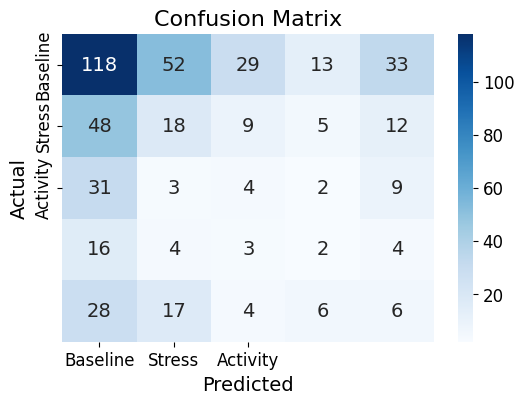

In [117]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = dc.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baseline','Stress','Activity'],
            yticklabels=['Baseline','Stress','Activity'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [118]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [133]:
import joblib
import pickle
import json

# Save Random Forest model
joblib.dump(rf, "/kaggle/working/random_forest_model.joblib")

# Also save as .pkl
with open("/kaggle/working/random_forest_model.pkl", "wb") as f:
    pickle.dump(rf, f)

# Save feature information
metadata = {
    "model": "RandomForestClassifier",
    "n_estimators": 200,
    "max_depth": 10,
    "random_state": 42,
    "n_features": 19,
    "features": [
        "ECG_mean_rr",
        "ECG_std_rr",
        "ECG_heart_rate",
        "ECG_hrv",

        "EDA_mean",
        "EDA_std",
        "EDA_max",
        "EDA_min",
        "EDA_num_peaks",

        "ACC_mean",
        "ACC_std",
        "ACC_max",
        "ACC_min",
        "ACC_rms",

        "TEMP_mean",
        "TEMP_std",
        "TEMP_max",
        "TEMP_min",
        "TEMP_slope"
    ]
}

with open("/kaggle/working/random_forest_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Model saved successfully!")

Model saved successfully!


In [134]:
import os

print(os.listdir("/kaggle/working"))

['random_forest_model_metadata.json', '.virtual_documents', 'random_forest_model.joblib', 'clients.pkl', 'random_forest_model.pkl', 'data_for_app.npz']


In [135]:
import pickle

with open("/kaggle/working/random_forest_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

sample = X_test[0].reshape(1, -1)

prediction = loaded_model.predict(sample)

print("Prediction:", prediction)
print("Actual:", y_test[0])

Prediction: [2]
Actual: 2


In [136]:
print(loaded_model.predict_proba(sample))

[[9.11982916e-02 0.00000000e+00 9.08665854e-01 4.76190476e-05
  8.82352941e-05]]


Accuracy: 0.976890756302521

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       245
           1       1.00      0.95      0.97        92
           2       1.00      1.00      1.00        49
           3       1.00      0.93      0.96        29
           4       1.00      0.93      0.97        61

    accuracy                           0.98       476
   macro avg       0.99      0.96      0.98       476
weighted avg       0.98      0.98      0.98       476



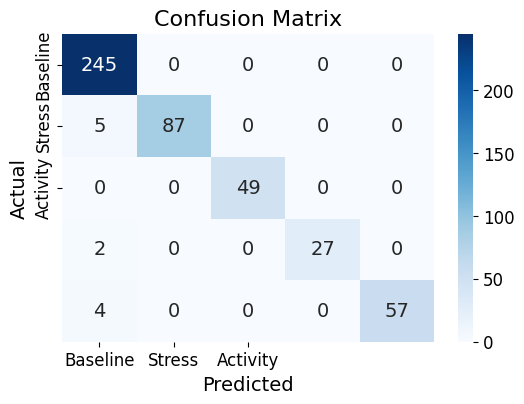

In [119]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baseline','Stress','Activity'],
            yticklabels=['Baseline','Stress','Activity'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [120]:
import numpy as np

# Pick a random test sample
i = np.random.randint(0, len(X_test))
sample = X_test[i].reshape(1, -1)
true_label = y_test[i]

# Predict
pred_label = rf.predict(sample)[0]

print("True label:", true_label)
print("Predicted label:", pred_label)


True label: 4
Predicted label: 4


In [121]:
proba = rf.predict_proba(sample)[0]
print("Class probabilities:", proba)


Class probabilities: [4.42389937e-02 0.00000000e+00 1.47058824e-04 1.53846154e-03
 9.54075486e-01]


In [122]:
# Pick a random baseline window
baseline_sample = X_test[y_test == 0][0].reshape(1, -1)
stress_sample   = X_test[y_test == 1][0].reshape(1, -1)
activity_sample = X_test[y_test == 2][0].reshape(1, -1)

print("Baseline →", rf.predict(baseline_sample)[0])
print("Stress   →", rf.predict(stress_sample)[0])
print("Activity →", rf.predict(activity_sample)[0])


Baseline → 0
Stress   → 1
Activity → 2


Total features: 26
Feature array shape: (2378, 19)


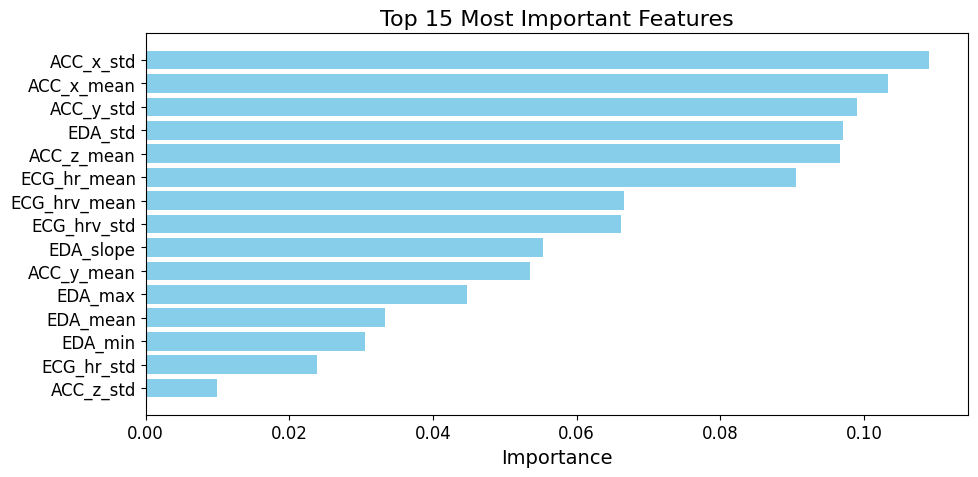

In [123]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define feature names per sensor
ecg_cols = [f'ECG_{f}' for f in ['mean', 'std', 'max', 'min', 'hr_mean', 'hr_std', 'hrv_mean', 'hrv_std']]
eda_cols = [f'EDA_{f}' for f in ['mean', 'std', 'max', 'min', 'slope']]
acc_cols = [f'ACC_{f}' for f in ['x_mean', 'x_std', 'y_mean', 'y_std', 'z_mean', 'z_std', 'mag_mean', 'mag_std']]
temp_cols = [f'TEMP_{f}' for f in ['mean', 'std', 'max', 'min', 'slope']]

# Combine all
feature_names = ecg_cols + eda_cols + acc_cols + temp_cols

# Safety check
print("Total features:", len(feature_names))
print("Feature array shape:", final_features.shape)

# Feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # top 15

plt.figure(figsize=(10,5))
plt.barh(range(15), importances[indices][::-1], color='skyblue')
plt.yticks(range(15), [feature_names[i] for i in indices][::-1])
plt.xlabel("Importance")
plt.title("Top 15 Most Important Features")
plt.tight_layout()
plt.show()


In [124]:
from sklearn.model_selection import StratifiedKFold , cross_val_score

rf_cv = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# 5-fold stratified CV to preserve label ratios
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [125]:
scores = cross_val_score(rf_cv, final_features, final_labels, cv=skf, scoring='accuracy', n_jobs=-1)

print("Cross-validation accuracies:", scores)
print("Mean Accuracy:", np.mean(scores))
print("Std Deviation:", np.std(scores))


Cross-validation accuracies: [0.96638655 0.97689076 0.9789916  0.95789474 0.98947368]
Mean Accuracy: 0.9739274657231313
Std Deviation: 0.010863012085561001


In [126]:
# STEP 1: refactor feature extraction into functions
import os
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

# --- CONFIG ---
FS = 700  # sampling rate for chest ECG in WESAD
WINDOW_SECONDS = 5
WINDOW_SIZE = WINDOW_SECONDS * FS
STEP_SIZE = WINDOW_SIZE // 2

# --- helpers ---
def load_subject_pkl(subject_path):
    import pickle
    with open(subject_path, "rb") as f:
        data = pickle.load(f, encoding='latin1')
    return data

def filter_labels_and_signals(labels, signal_array, keep_labels=[0,1,2,3,4]):
    # returns filtered signal (aligned) and filtered labels (per-sample)
    mask = np.isin(labels, keep_labels)
    return signal_array[mask], labels[mask]

def make_windows_and_labels(signal, labels_resampled, fs=FS, window_size=WINDOW_SIZE, step_size=STEP_SIZE):
    features = []
    window_labels = []
    for start in range(0, len(signal) - window_size, step_size):
        end = start + window_size
        window = signal[start:end]
        if window.ndim > 1:
            window = window[:,0]  # take first channel if multi-dim
        peaks, _ = find_peaks(window, distance=200)
        if len(peaks) < 2:
            continue
        rr_intervals = np.diff(peaks) / fs
        mean_rr = float(np.mean(rr_intervals))
        std_rr = float(np.std(rr_intervals))
        heart_rate = float(60.0 / mean_rr) if mean_rr>0 else 0.0
        hrv = float(std_rr)
        features.append([mean_rr, std_rr, heart_rate, hrv])
        wlab = labels_resampled[start:end]
        if len(wlab)==0:
            continue
        counts = np.bincount(wlab)
        window_labels.append(int(np.argmax(counts)))
    return np.array(features, dtype=float), np.array(window_labels, dtype=int)

def generic_window_features(signal, labels_resampled, window_size=WINDOW_SIZE, step_size=STEP_SIZE, extra_stats=True):
    feats = []
    wlabels = []
    for start in range(0, len(signal) - window_size, step_size):
        end = start + window_size
        w = signal[start:end]
        if w.ndim > 1:
            w = w[:,0]
        if len(w)==0:
            continue
        mean_val = float(np.mean(w))
        std_val = float(np.std(w))
        max_val = float(np.max(w))
        min_val = float(np.min(w))
        slope = float((w[-1] - w[0]) / len(w))
        # count peaks as an additional feature when applicable
        pks, _ = find_peaks(w, height=np.mean(w))
        num_peaks = int(len(pks))
        feats.append([mean_val, std_val, max_val, min_val, slope, num_peaks])
        wl = labels_resampled[start:end]
        if len(wl)==0:
            continue
        counts = np.bincount(wl)
        wlabels.append(int(np.argmax(counts)))
    return np.array(feats, dtype=float), np.array(wlabels, dtype=int)

# --- main function: extract dataset for a single subject object ---
def extract_features_from_subject(subject_data):
    # subject_data is already loaded pickle dict
    # 1) get raw arrays
    chest = subject_data['signal']['chest']
    labels = subject_data['label']
    # 2) filter labels to keep useful ones
    keep = [0,1,2,3,4]
    # ECG
    ecg = chest['ECG']
    # EDA
    eda = chest['EDA']
    # ACC magnitude
    acc = chest['ACC']
    acc_mag = np.sqrt(np.sum(acc**2, axis=1))
    # TEMP
    temp = chest['Temp']
    # Filter labels per-sample (keep indices where label in keep)
    mask = np.isin(labels, keep)
    labels_clean = labels[mask]
    # For per-signal alignment, trim signals to mask length if same sample alignment exists
    # If signal lengths differ from labels, we resample labels to match signal length for windowing.
    def resample_labels_for_signal(sig):
        rep = np.repeat(labels_clean, len(sig) // len(labels_clean) + 1)
        return rep[:len(sig)]
    # ECG windows (R-peak based)
    ecg_f, ecg_l = make_windows_and_labels(ecg[mask] if ecg.shape[0]==mask.sum() else ecg, resample_labels_for_signal(ecg))
    # EDA windows
    eda_f, eda_l = generic_window_features(eda if eda.shape[0]!=0 else np.array([]), resample_labels_for_signal(eda))
    # ACC windows
    acc_f, acc_l = generic_window_features(acc_mag, resample_labels_for_signal(acc_mag))
    # TEMP windows
    temp_f, temp_l = generic_window_features(temp, resample_labels_for_signal(temp))
    # Trim to minimum length across modalities
    arrays = [ecg_f, eda_f, acc_f, temp_f]
    lengths = [a.shape[0] for a in arrays if a is not None and a.size>0]
    if len(lengths)==0:
        raise ValueError("No windows created for subject.")
    min_len = min(lengths)
    ecg_f = ecg_f[:min_len]
    eda_f = eda_f[:min_len]
    acc_f = acc_f[:min_len]
    temp_f = temp_f[:min_len]
    # stack horizontally
    final_features = np.hstack([ecg_f, eda_f, acc_f, temp_f])
    final_labels = ecg_l[:min_len]  # use ECG-derived window labels (aligned)
    return final_features, final_labels

# --- helper to run on a single subject file path ---
def build_dataset_from_subject_path(subject_path):
    subj = load_subject_pkl(subject_path)
    X, y = extract_features_from_subject(subj)
    return X, y



In [127]:
# -------------------------
# RUN this cell on your S2 file and print checks
subject_path = "/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD/S2/S2.pkl"
X, y = build_dataset_from_subject_path(subject_path)

print("FEATURES shape:", X.shape)
print("LABELS shape:", y.shape)
print("LABEL distribution:\n", pd.Series(y).value_counts().sort_index())
# quick sanity rows
print("First feature row (len={}):".format(X.shape[1]), X[0])


FEATURES shape: (2430, 22)
LABELS shape: (2430,)
LABEL distribution:
 0    1023
1     915
2     492
Name: count, dtype: int64
First feature row (len=22): [ 3.61208791e-01  6.01824702e-02  1.66108914e+02  6.01824702e-02
  5.91772635e+00  4.83972888e-01  6.48841858e+00  5.21621704e+00
  2.43159703e-04  8.04000000e+02  9.30919672e-01  4.89865568e-02
  1.50603942e+00  5.22995439e-01 -5.83141084e-05  4.21000000e+02
  3.00994759e+01  2.51853950e-02  3.02646484e+01  3.00554504e+01
 -9.53020390e-06  6.86000000e+02]


In [128]:
# STEP 2: create clients (IID and non-IID options) and inspect them
import numpy as np
import pandas as pd
from collections import Counter

def create_clients_iid(X, y, n_clients=4, seed=42):
    np.random.seed(seed)
    idx = np.random.permutation(len(X))
    sizes = [len(X) // n_clients] * n_clients
    for i in range(len(X) % n_clients):
        sizes[i] += 1
    clients = {}
    ptr = 0
    for i, s in enumerate(sizes):
        sel = idx[ptr:ptr+s]
        clients[f'client_{i}'] = (X[sel], y[sel])
        ptr += s
    return clients

def create_clients_non_iid_by_label_frac(X, y, n_clients=4, seed=42):
    """
    Simple non-iid: create clients where each client has a dominant label.
    We allocate fractions of each label to each client so distribution differs.
    """
    np.random.seed(seed)
    clients = {f'client_{i}': ([], []) for i in range(n_clients)}
    labels = np.unique(y)
    for lbl in labels:
        idx_lbl = np.where(y == lbl)[0]
        np.random.shuffle(idx_lbl)
        # split indices of this label into n_clients chunks (unequal sizes)
        splits = np.array_split(idx_lbl, n_clients)
        for i, chunk in enumerate(splits):
            clients[f'client_{i}'][0].append(X[chunk])
            clients[f'client_{i}'][1].append(y[chunk])
    # concatenate arrays per client and convert to numpy
    out = {}
    for i in range(n_clients):
        Xparts = clients[f'client_{i}'][0]
        Yparts = clients[f'client_{i}'][1]
        if len(Xparts) > 0:
            Xc = np.vstack(Xparts)
            yc = np.hstack(Yparts)
        else:
            Xc = np.zeros((0, X.shape[1]))
            yc = np.array([], dtype=int)
        out[f'client_{i}'] = (Xc, yc)
    return out

# Use the X,y you already created in Step 1
n_clients = 4

clients_iid = create_clients_iid(X, y, n_clients=n_clients)
clients_non_iid = create_clients_non_iid_by_label_frac(X, y, n_clients=n_clients)

def inspect_clients(clients_dict, name="clients"):
    print(f"--- Inspecting {name} ---")
    total_samples = 0
    for cid, (Xc, yc) in clients_dict.items():
        total_samples += len(Xc)
        print(f"{cid}: samples={len(Xc)}, features={Xc.shape[1] if Xc.size else 'NA'}, label_counts={dict(pd.Series(yc).value_counts().to_dict())}")
    print("Total samples across clients:", total_samples)
    print()

# Print IID
inspect_clients(clients_iid, "IID clients")

# Print non-IID
inspect_clients(clients_non_iid, "Non-IID clients")

# Save the version you want to use going forward (choose one)
clients = clients_non_iid  # <-- change to clients_iid if you prefer IID

# Quick check: pick a random client sample for later debug
sample_client = list(clients.keys())[0]
print("Example client chosen for next steps:", sample_client)
print("Example shapes:", clients[sample_client][0].shape, clients[sample_client][1].shape)


--- Inspecting IID clients ---
client_0: samples=608, features=22, label_counts={0: 250, 1: 235, 2: 123}
client_1: samples=608, features=22, label_counts={0: 242, 1: 237, 2: 129}
client_2: samples=607, features=22, label_counts={0: 270, 1: 217, 2: 120}
client_3: samples=607, features=22, label_counts={0: 261, 1: 226, 2: 120}
Total samples across clients: 2430

--- Inspecting Non-IID clients ---
client_0: samples=608, features=22, label_counts={0: 256, 1: 229, 2: 123}
client_1: samples=608, features=22, label_counts={0: 256, 1: 229, 2: 123}
client_2: samples=608, features=22, label_counts={0: 256, 1: 229, 2: 123}
client_3: samples=606, features=22, label_counts={0: 255, 1: 228, 2: 123}
Total samples across clients: 2430

Example client chosen for next steps: client_0
Example shapes: (608, 22) (608,)


In [129]:
# STEP 3: small PyTorch MLP + local training on one client
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import accuracy_score

# --- model ---
class SmallMLP(nn.Module):
    def __init__(self, in_dim, hidden=64, out_dim=3):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden, out_dim)
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# --- helpers ---
def get_state_dict_cpu(model):
    return {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}

def set_state_dict(model, state_dict):
    model.load_state_dict(state_dict)

def train_local(model, X, y, epochs=5, batch_size=32, lr=1e-3, device='cpu', verbose=True):
    model = model.to(device)
    optimz = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    y_t = torch.tensor(y, dtype=torch.long).to(device)
    dataset = torch.utils.data.TensorDataset(X_t, y_t)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    model.train()
    for e in range(1, epochs+1):
        epoch_losses = []
        for xb, yb in loader:
            optimz.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            optimz.step()
            epoch_losses.append(loss.item())
        if verbose:
            print(f"Epoch {e:02d}/{epochs} — loss: {np.mean(epoch_losses):.4f}")
    return get_state_dict_cpu(model)

def evaluate_model(model, X, y, device='cpu'):
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        out = model(X_t)
        preds = torch.argmax(out, dim=1).cpu().numpy()
    acc = accuracy_score(y, preds)
    return acc, preds




In [130]:
# --- Run training on selected client (client_0) ---
client_id = "client_0"
Xc, yc = clients[client_id]   # clients variable from previous step
print(f"Training local model on {client_id}: samples={len(Xc)}, classes={np.unique(yc)}")

in_dim = Xc.shape[1]
out_dim = len(np.unique(y))   # global label count from Step 1
torch.manual_seed(42)

local_model = SmallMLP(in_dim=in_dim, hidden=64, out_dim=out_dim)
local_params = train_local(local_model, Xc, yc, epochs=5, batch_size=32, lr=1e-3, device='cpu', verbose=True)

# Evaluate local model on its own client data (quick sanity)
set_state_dict(local_model, local_params)
acc, preds = evaluate_model(local_model, Xc, yc)
print(f"Local eval accuracy on {client_id}: {acc:.4f}")

# Print small parameter summary (keys, shapes, first 5 values of fc1 weight)
print("Param keys and shapes:")
for k, v in local_params.items():
    print(f" - {k}: {tuple(v.shape)}")
print("First 5 values of fc1.weight flattened:", local_params['fc1.weight'].flatten()[:5].numpy())

Training local model on client_0: samples=608, classes=[0 1 2]
Epoch 01/5 — loss: 30.9343
Epoch 02/5 — loss: 8.2828
Epoch 03/5 — loss: 3.1168
Epoch 04/5 — loss: 1.6637
Epoch 05/5 — loss: 1.4293
Local eval accuracy on client_0: 0.3882
Param keys and shapes:
 - fc1.weight: (64, 22)
 - fc1.bias: (64,)
 - fc2.weight: (3, 64)
 - fc2.bias: (3,)
First 5 values of fc1.weight flattened: [ 0.16300017  0.17695828 -0.04994706  0.19584858 -0.04671304]


In [131]:
# STEP 4: train second client, average params (FedAvg), evaluate
import torch
import numpy as np
from copy import deepcopy
from sklearn.metrics import accuracy_score

# Reuse SmallMLP, train_local, set_state_dict, get_state_dict_cpu, evaluate_model from Step 3
# If you restarted the kernel, re-run the Step 3 cell first.

# Helper: FedAvg for state_dicts
def fed_avg(state_dicts, weights=None):
    """Average a list of state_dicts. weights optional list same length as state_dicts."""
    n = len(state_dicts)
    if weights is None:
        weights = [1.0 / n] * n
    avg = {}
    for k in state_dicts[0].keys():
        stacked = torch.stack([sd[k].float() * w for sd, w in zip(state_dicts, weights)], dim=0)
        avg[k] = torch.sum(stacked, dim=0)
    return avg

# 1) Ensure client_0 params exist (from your run). If not, train quickly again.
if 'local_params' not in globals():
    print("local_params not found in globals; training client_0 again.")
    client_id = "client_0"
    Xc, yc = clients[client_id]
    local_model = SmallMLP(in_dim=Xc.shape[1], hidden=64, out_dim=len(np.unique(y)))
    local_params = train_local(local_model, Xc, yc, epochs=3, batch_size=32, lr=1e-3, verbose=False)
else:
    print("Using existing local_params for client_0")

# 2) Train client_1 and save params
client_id2 = "client_1"
Xc2, yc2 = clients[client_id2]
print(f"Training local model on {client_id2}: samples={len(Xc2)}, classes={np.unique(yc2)}")
local_model2 = SmallMLP(in_dim=Xc2.shape[1], hidden=64, out_dim=len(np.unique(y)))
local_params_1 = train_local(local_model2, Xc2, yc2, epochs=5, batch_size=32, lr=1e-3, verbose=True)

# 3) Collect state dicts for averaging
state_list = [local_params, local_params_1]  # client_0 and client_1
# Optionally weight by client sizes
sizes = [len(clients['client_0'][0]), len(clients['client_1'][0])]
weights = [s / sum(sizes) for s in sizes]
print("Client sizes:", sizes, "FedAvg weights:", [round(w,3) for w in weights])

# 4) FedAvg -> global params
global_params = fed_avg(state_list, weights=weights)

# 5) Create a fresh global model and load aggregated params
global_model = SmallMLP(in_dim=X.shape[1], hidden=64, out_dim=len(np.unique(y)))
set_state_dict(global_model, global_params)

# 6) Evaluate: local models vs global model
def eval_on_dataset(state_dict, X_eval, y_eval):
    m = SmallMLP(in_dim=X_eval.shape[1], hidden=64, out_dim=len(np.unique(y)))
    set_state_dict(m, state_dict)
    acc, _ = evaluate_model(m, X_eval, y_eval)
    return acc

acc_c0_local = eval_on_dataset(local_params, clients['client_0'][0], clients['client_0'][1])
acc_c1_local = eval_on_dataset(local_params_1, clients['client_1'][0], clients['client_1'][1])
acc_c0_global = eval_on_dataset(global_params, clients['client_0'][0], clients['client_0'][1])
acc_c1_global = eval_on_dataset(global_params, clients['client_1'][0], clients['client_1'][1])
acc_global_on_all = eval_on_dataset(global_params, X, y)

# 7) Parameter summaries (L2 norm of fc1.weight and fc2.weight)
def param_norms(state):
    w1 = state['fc1.weight'].float()
    w2 = state['fc2.weight'].float()
    return float(torch.norm(w1).item()), float(torch.norm(w2).item())

import torch
norm_c0 = param_norms(local_params)
norm_c1 = param_norms(local_params_1)
norm_global = param_norms(global_params)

# 8) Print concise results (paste these back)
print("\n--- Results (paste these lines) ---")
print(f"Client_0 local acc: {acc_c0_local:.4f}")
print(f"Client_1 local acc: {acc_c1_local:.4f}")
print(f"Client_0 with aggregated global acc: {acc_c0_global:.4f}")
print(f"Client_1 with aggregated global acc: {acc_c1_global:.4f}")
print(f"Aggregated global model acc on full dataset X,y: {acc_global_on_all:.4f}")
print()
print("Param L2 norms (fc1, fc2):")
print(f" client_0: {norm_c0}")
print(f" client_1: {norm_c1}")
print(f" aggregated_global: {norm_global}")
print("\nFirst 5 values of aggregated fc1.weight flattened:", global_params['fc1.weight'].flatten()[:5].numpy())


Using existing local_params for client_0
Training local model on client_1: samples=608, classes=[0 1 2]
Epoch 01/5 — loss: 25.9432
Epoch 02/5 — loss: 5.7206
Epoch 03/5 — loss: 2.4634
Epoch 04/5 — loss: 1.5662
Epoch 05/5 — loss: 1.5049
Client sizes: [608, 608] FedAvg weights: [0.5, 0.5]

--- Results (paste these lines) ---
Client_0 local acc: 0.3882
Client_1 local acc: 0.4145
Client_0 with aggregated global acc: 0.4408
Client_1 with aggregated global acc: 0.4293
Aggregated global model acc on full dataset X,y: 0.4403

Param L2 norms (fc1, fc2):
 client_0: (4.679986000061035, 0.8939207792282104)
 client_1: (4.593334674835205, 0.9979988932609558)
 aggregated_global: (3.2813656330108643, 0.6782481670379639)

First 5 values of aggregated fc1.weight flattened: [ 0.07853946 -0.00774591  0.00901879  0.02005947 -0.08190004]


In [132]:
# SAVE DATA FOR STREAMLIT APP
import numpy as np, pickle, os
np.savez('data_for_app.npz', X=final_features, y=final_labels)
with open('clients.pkl', 'wb') as f:
    pickle.dump(clients, f)
print("Saved data_for_app.npz and clients.pkl to", os.getcwd())


Saved data_for_app.npz and clients.pkl to /kaggle/working
